### Importing basic libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Creating random 500 real like data.

In [32]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    'Age': np.random.randint(21, 60, 10000),
    'Salary': np.random.randint(15000, 150000, 10000),
    'CIBIL_Score': np.random.randint(300, 900, 10000)
}

df = pd.DataFrame(data)

df['Loan_Status'] = np.where((df['Salary'] > 40000) & (df['CIBIL_Score'] > 650), 1, 0)

print(df.head(10))
print("\nData Shape:", df.shape)

   Age  Salary  CIBIL_Score  Loan_Status
0   59   36381          685            0
1   49   98108          558            0
2   35   64892          776            1
3   28  106501          310            0
4   41   98391          559            0
5   59   32920          692            0
6   39   31702          899            0
7   43   16894          668            0
8   31   45985          483            0
9   31  140702          315            0

Data Shape: (10000, 4)


#### Importing prediction model libraries.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df.head()

,Age,Salary,CIBIL_Score,Loan_Status
0,59,99076,350,0
1,49,104780,563,0
2,35,36689,717,0
3,28,26174,395,0
4,41,103461,387,0


#### Defining data into X & y variable.

In [33]:
X = df[['Age','Salary','CIBIL_Score']]
y = df['Loan_Status']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2,random_state = 42)  # defining variable data in train test split for testing.

#### Scaling the test data.

In [35]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = LogisticRegression()  # model defining in variable.

In [36]:
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Predicting the answer according to test data.

In [37]:
prediction = model.predict(X_test_scaled)
prediction

array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

#### Finding the accuracy percentage, score, and confusion matrix along with report.

In [38]:
score = accuracy_score(y_test,prediction)
cf = confusion_matrix(y_test,prediction)
print(score * 100)

90.0


In [39]:
cf

array([[1258,   96],
       [ 104,  542]])

In [40]:
report = classification_report(y_test,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1354
           1       0.85      0.84      0.84       646

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.90      0.90      0.90      2000



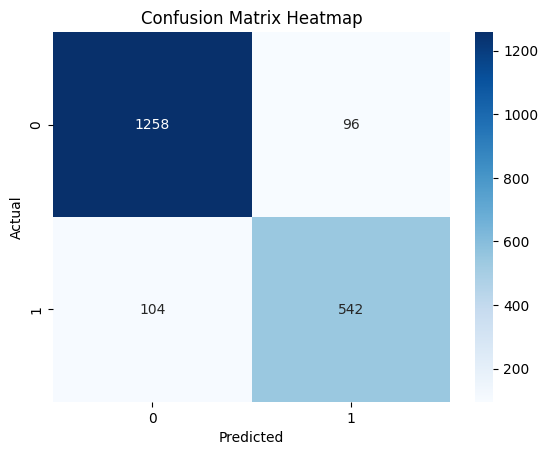

In [41]:
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()